<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Machine Learning Project
MoraGarcia Carmen, De Artiagoitia Léo, Dubouchet Chloé et Perrin Alicia


## Introduction

The data is taken from the KAGGLE competition website; it is the data set "Cardivascular Disease Risk
Prediction Dataset" available here: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovasculardisease-risk-prediction-dataset.


This dataset contains 15,000 synthetic patient medical records specifically designed to predict the risk of
cardiovascular disease. Although synthetic, the data is generated using medical heuristics to ensure realistic
correlations between variables, such as the relationship between age, BMI, and blood pressure. The dataset
includes 19 variables for 15,000 patients.

**WARNING** In order to have exactly the same training and test samples in both languages ​​so that their results can be compared afterwards, it is imperative to run the python notebook before this one.

In [57]:
options(warn = -1)
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(fastDummies)

## 1. Exploratory data analysis

## a. Read the table of data

In [31]:
df<-read.csv("archive/healthcare_synthetic_data.csv", sep=",")
head(df)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


We start by checking the nature of the different variables and their encoding.

In [32]:
df$Gender <- factor(df$Gender, labels = c("Woman", "Man"))

df$Smoking_Status <- factor(df$Smoking_Status, labels = c("Non_Smoker", "Smoker"))

df$Alcohol_Consumption <- factor(df$Alcohol_Consumption, labels = c("Non", "Moderate", "Heavy"))

df$Physical_Activity_Level <- factor(df$Physical_Activity_Level)

df$Family_History <- factor(df$Family_History, labels = c("No", "Yes"))

df$Heart_Disease_Risk <- factor(df$Heart_Disease_Risk, labels = c("Low", "High"))

Secondly, we transform some variable to be Gaussian.

In [33]:
df <- df %>%
  mutate(
    R_Weight_kg = sqrt(Weight_kg),
    R_BMI = sqrt(BMI)
  )

variables <- c('Age', 'Height_cm', 'R_Weight_kg', 'R_BMI', 'Systolic_BP', 
               'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 
               'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 
               'Sleep_Hours')

df <- df %>% 
  select(-BMI, -Weight_kg)

summary(df)

  Patient_ID             Age          Gender       Height_cm    
 Length:15000       Min.   :25.00   Woman:7622   Min.   :138.5  
 Class :character   1st Qu.:46.00   Man  :7378   1st Qu.:158.5  
 Mode  :character   Median :55.00                Median :164.7  
                    Mean   :54.54                Mean   :165.3  
                    3rd Qu.:63.00                3rd Qu.:172.0  
                    Max.   :85.00                Max.   :198.1  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  
 Cholesterol_HDL Fasting_Blood_Sugar    Smoking_Status  Alcohol_Consu

# 2. Prediction of Heart’s Disease Risk
We consider the problem of predicting the variable Heart_Disease_Risk from the other variables from a machine learning point of view, i.e. focusing on model performance. The aim is to determine the best performance we can expect, and which models achieve it.

## a. Importation of training sample and a test sample

We decided to export the indices of the individuals in each sample so that we could compare the results obtained in R and in Python on the same data.

In [34]:
train_idx <- read.csv("train_indices.csv")$index
test_idx <- read.csv("test_indices.csv")$index

train_idx_r <- train_idx + 1
test_idx_r <- test_idx + 1

df_train <- df[train_idx_r, ]
df_test <- df[test_idx_r, ]

set.seed(42)

In [69]:
X_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk"))]
Y_train <- as.numeric(df_train$Heart_Disease_Risk) - 1  
X_test  <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk"))]
Y_test  <- as.numeric(df_test$Heart_Disease_Risk) - 1   

# Variables quantitatives à scaler
quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP",
            "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
            "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

X_train_scaled <- scale(X_train[, quanti])
X_train[, quanti] <- X_train_scaled
X_test[, quanti]  <- scale(X_test[, quanti],
                            center = attr(X_train_scaled, "scaled:center"),
                            scale  = attr(X_train_scaled, "scaled:scale"))

# Version pour glm/lasso (factors conservés)
Xr_train <- as.data.frame(X_train)
Xr_test  <- as.data.frame(X_test)

# Version pour svm/glmnet (tout numérique, dummy encoding)

Xr_train <- dummy_cols(Xr_train, remove_first_dummy = TRUE, remove_selected_columns = TRUE)
Xr_test  <- dummy_cols(Xr_test,  remove_first_dummy = TRUE, remove_selected_columns = TRUE)

Xr_train <- as.data.frame(lapply(Xr_train, as.numeric))
Xr_test  <- as.data.frame(lapply(Xr_test,  as.numeric))

# Aligner les colonnes (sécurité)
Xr_test <- Xr_test[, colnames(Xr_train)]

In [59]:
summary(probs_simple)  # toutes les probas > 0.5 ou toutes < 0.5 ?
table(preds_simple, Y_test)  # la confusion matrix révèle tout

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.01118 0.21068 0.39872 0.44130 0.66441 0.99231 

            Y_test
preds_simple    0    1
           0 1339  469
           1  323  869

## b. Comparison of forecasting models

### i) Linear model

In [60]:

# We use glm for the binomial family
logit_simple <- glm(Heart_Disease_Risk ~ ., data = cbind(Xr_train, Heart_Disease_Risk = Y_train), family = binomial)

# test error
probs_simple <- predict(logit_simple, newdata = Xr_test, type = "response")
preds_simple <- ifelse(probs_simple > 0.5, 1, 0)
err_simple <- mean(preds_simple != Y_test)

cat(sprintf("Model error without selection : %.4f\n", err_simple))

Model error without selection : 0.2640


In [61]:
set.seed(42)
x_train_mat <- as.matrix(Xr_train)
y_train_vec <- as.numeric(Y_train)


cv_lasso <- cv.glmnet(x_train_mat, y_train_vec, family = "binomial", alpha = 1, nfolds = 5, type.measure = "class")# in glmnet, alpha = 1 is equivalent to the lasso + automatic cross validation

best_lambda <- cv_lasso$lambda.min
cat("Best lambda =", best_lambda, "\n")

# Note : the error of CV is stocked in cv_lasso$cvm !!
cat(sprintf("Best score (error CV) = %f\n", min(cv_lasso$cvm)))

Best lambda = 0.003655039 
Best score (error CV) = 0.351833


In [62]:
# Prediction with the best lambda found
probs_opt <- predict(cv_lasso, newx = as.matrix(Xr_test), s = "lambda.min", type = "response")
preds_opt <- ifelse(probs_opt > 0.5, 1, 0)

# test error
err_test_lasso <- mean(preds_opt != Y_test)
cat(sprintf("Error on the test sample : %.4f\n", err_test_lasso))

Error on the test sample : 0.3557


In [63]:
# finding the coeffs for the best lambdas
coeffs_lasso <- coef(cv_lasso, s = "lambda.min")
df_coeffs <- data.frame(
  Variable = rownames(coeffs_lasso),
  Coeff = as.vector(coeffs_lasso)
)

# Note: we delet the intercept to find the combinations
df_coeffs_vars <- df_coeffs[df_coeffs$Variable != "(Intercept)", ]
variables_supprimees <- df_coeffs_vars[df_coeffs_vars$Coeff == 0, "Variable"]

cat(sprintf("Number of deleted variables by Lasso : %d\n", length(variables_supprimees)))
cat("Deleted variables :", paste(variables_supprimees, collapse = ", "), "\n")

Number of deleted variables by Lasso : 7
Deleted variables : Gender, Height_cm, Diastolic_BP, Cholesterol_Total, Smoking_Status, Alcohol_Consumption, Family_History 


Lasso keeps 10 variables and deletes 7 of them


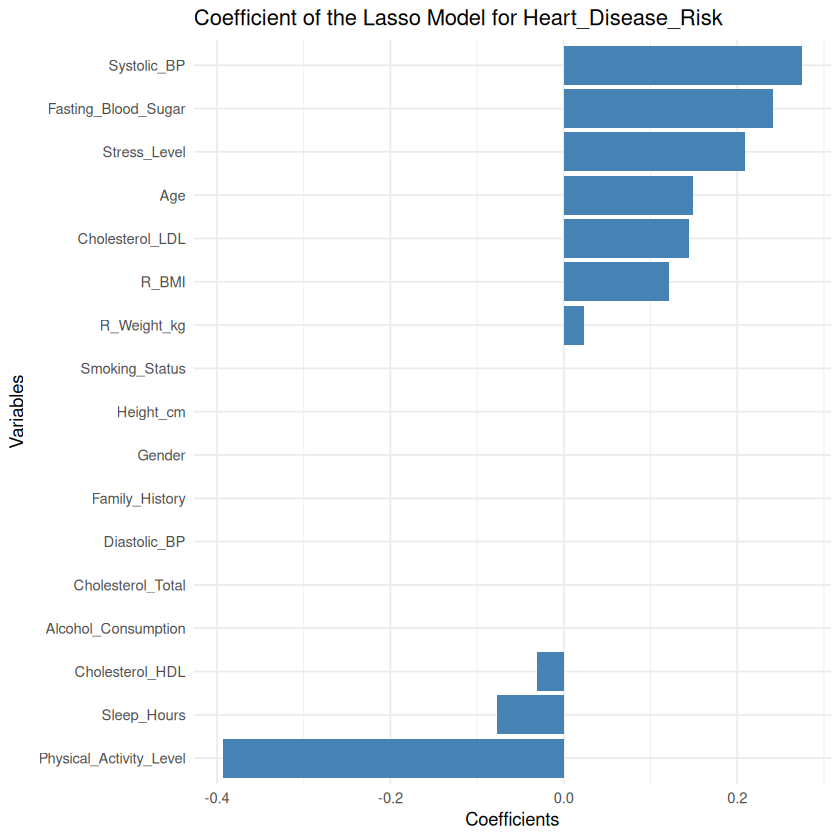

In [64]:
df_coeffs_vars <- df_coeffs_vars[order(df_coeffs_vars$Coeff), ]

cat("Lasso keeps", sum(df_coeffs_vars$Coeff != 0), "variables and deletes", sum(df_coeffs_vars$Coeff == 0), "of them\n")

# graph
ggplot(df_coeffs_vars, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Coefficient of the Lasso Model for Heart_Disease_Risk",
    x = "Variables",
    y = "Coefficients"
  ) +
  theme_minimal()

In [65]:
# Class prediction (Threshold= 0.5 par défaut)
y_chap <- ifelse(probs_opt > 0.5, 1, 0)

# matrix confusion
table_confusion <- table(Predicton = y_chap, Reel = Y_test)
print(table_confusion)

         Reel
Predicton    0    1
        0 1270  675
        1  392  663


In [66]:

library(caret)
conf_matrix <- confusionMatrix(as.factor(y_chap), as.factor(Y_test), positive = "1")
print(conf_matrix)

# equivalent to AUC
roc_lasso <- roc(Y_test, as.vector(probs_opt))
cat(sprintf("AUC of the Lasso Model : %.4f\n", auc(roc_lasso)))

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1270  675
         1  392  663
                                          
               Accuracy : 0.6443          
                 95% CI : (0.6269, 0.6615)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.2651          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.4955          
            Specificity : 0.7641          
         Pos Pred Value : 0.6284          
         Neg Pred Value : 0.6530          
             Prevalence : 0.4460          
         Detection Rate : 0.2210          
   Detection Prevalence : 0.3517          
      Balanced Accuracy : 0.6298          
                                          
       'Positive' Class : 1               
                        

Setting levels: control = 0, case = 1

Setting direction: controls < cases



AUC of the Lasso Model : 0.6912


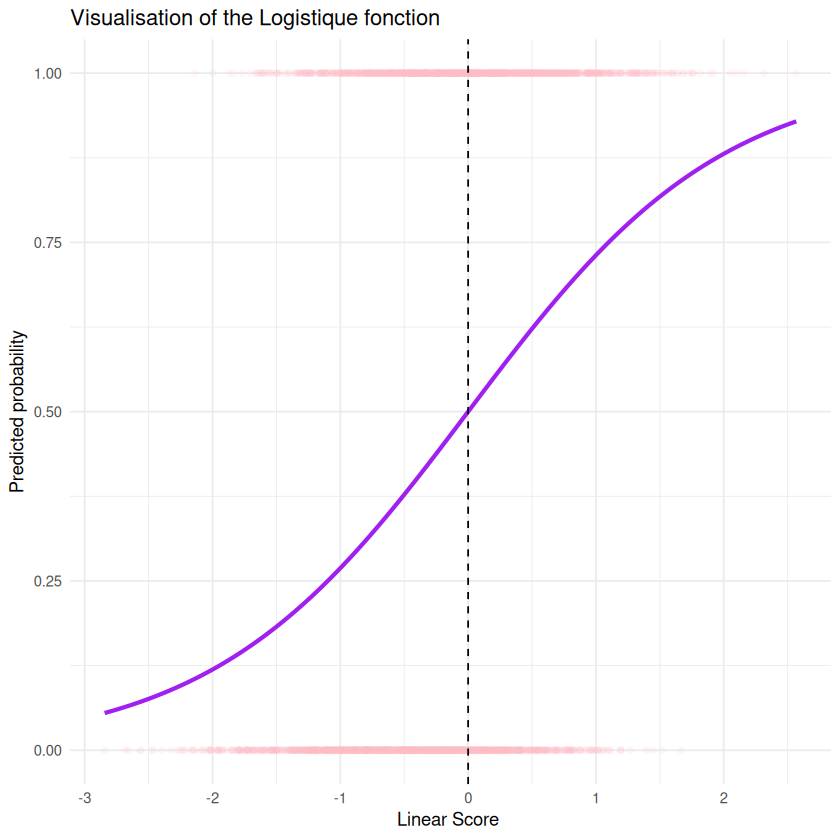

In [67]:
# Calcul of the linear score 
z <- predict(cv_lasso, newx = as.matrix(Xr_test), s = "lambda.min", type = "link")

# sigmoide curve
z_range <- seq(min(z), max(z), length.out = 1000)
p_range <- 1 / (1 + exp(-z_range))

# Graph using ggplot2
df_viz <- data.frame(z = as.vector(z), real = as.factor(Y_test))
df_curve <- data.frame(z_range = z_range, p_range = p_range)

ggplot() +
  geom_point(data = df_viz, aes(x = z, y = as.numeric(as.character(real))), 
             alpha = 0.1, color = "pink") +
  geom_line(data = df_curve, aes(x = z_range, y = p_range), color = "purple", size = 1.2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(title = "Visualisation of the Logistique fonction ",
       x = "Linear Score ", y = "Predicted probability") +
  theme_minimal()

### ii)  SVR/SVM

In [15]:
library(e1071)   #  SVM
library(caret)   #   Grid Search

In [70]:
set.seed(42)
svm_lin_tune <- tune(svm, 
                     train.x = as.matrix(Xr_train), 
                     train.y = as.factor(Y_train),
                     kernel = "linear",
                     ranges = list(cost = c(0.1, 0.4, 0.5, 0.6, 0.8, 1, 1.4, 2)))

print("===Linear SVM  ===")
cat("Best C :", svm_lin_tune$best.parameters$cost, "\n")
cat(sprintf("Error CV  : %.4f\n", svm_lin_tune$best.performance))

# Error test
pred_svm_lin <- predict(svm_lin_tune$best.model, newdata = as.matrix(Xr_test))
err_test_svm <- mean(pred_svm_lin != Y_test)
cat(sprintf("Error test : %.4f\n", err_test_svm))

[1] "===Linear SVM  ==="
Best C : 2 
Error CV  : 0.2700
Error test : 0.2713


In [ ]:

param_grid <- expand.grid(
  C = c(0.5, 1, 2, 5, 10),
  gamma = c(0.01, 0.001) # Note: R use 'scale'/'auto' by default
)

results_file <- "gridsearch_progress.csv"
cat("Beginning :", nrow(param_grid), "combinaision to test\n")

for(i in 1:nrow(param_grid)) {
  p <- param_grid[i, ]
  cat(sprintf("Test %d/%d : C=%s, gamma=%s... ", i, nrow(param_grid), p$C, p$gamma))

  model_tune <- tune(svm, 
                    train.x = as.matrix(Xr_train), 
                    train.y = as.factor(Y_train),
                    kernel = "radial",
                    ranges = list(cost = p$C, gamma = p$gamma),
                    tunecontrol = tune.control(cross = 10))
  
  current_accuracy <- 1 - model_tune$best.performance
  
  # Save in the CSV
  res <- data.frame(
    params = paste0("C=", p$C, ", gamma=", p$gamma),
    accuracy = current_accuracy,
    error = 1 - current_accuracy
  )
  
  write.table(res, file = results_file, append = file.exists(results_file), 
              sep = ",", row.names = FALSE, col.names = !file.exists(results_file))
  
  cat(sprintf("OK (Score: %.4f)\n", current_accuracy))
}

cat("\nDone !!\n")

In [ ]:

df_results <- read.csv("gridsearch_progress.csv")


best_row <- df_results[which.max(df_results$accuracy), ]
cat("Meilleurs paramètres trouvés :", best_row$params, "\n")

best_c <- as.numeric(gsub(".*C=([0-9.]+).*", "\\1", best_row$params))
best_gamma <- as.numeric(gsub(".*gamma=([0-9.]+).*", "\\1", best_row$params))

# Note: probability = TRUE necessary to have the score later
best_svm <- svm(train.x = as.matrix(Xr_train), 
                train.y = as.factor(Y_train), 
                kernel = "radial", 
                cost = best_c, 
                gamma = best_gamma, 
                probability = TRUE)

In [ ]:

y_pred <- predict(best_svm, newdata = as.matrix(Xr_test))


table_final <- table(Prédit = y_pred, Réel = Y_test)
print(table_final)

levels(y_pred) <- c("Low Risk (0)", "High Risk (1)")
Y_test_factor <- as.factor(Y_test)
levels(Y_test_factor) <- c("Low Risk (0)", "High Risk (1)")

final_report <- confusionMatrix(y_pred, Y_test_factor)
print(final_report)

cat("\n--- Metric details ---\n")
print(final_report$byClass[c("Precision", "Recall", "F1")])

### iii) Optimal tree

The main hyperparameter of a decision tree is maxdepth: it controls how many times the tree 
can split the data. A tree that is too shallow (depth 1-2) is too simple and misses important 
patterns (underfitting). A tree that is too deep memorizes the training data but fails on new 
data (overfitting). To find the best depth, we use cross-validation: it tries every depth from 
1 to 20 and averages the accuracy. This way we choose the depth that generalizes best to unseen data.

In [17]:
library(rpart)
library(rpart.plot)

In [18]:
cv_accuracy <- c()

for (d in 1:20) {
  tree_d <- rpart(
    Heart_Disease_Risk ~ .,
    data = cbind(X_train, Heart_Disease_Risk = Y_train),
    method = "class",
    control = rpart.control(maxdepth = d, cp = 0)
  )
  pred_d <- predict(tree_d, X_test, type = "class")
  acc <- mean(pred_d == Y_test)
  cv_accuracy <- c(cv_accuracy, acc)
}

best_depth <- which.max(cv_accuracy)
cat("Best maxdepth :", best_depth, "\n")
cat("Best accuracy :", round(max(cv_accuracy), 4), "\n")

Best maxdepth : 4 
Best accuracy : 0.704 


This plot shows the cross-validation accuracy for each depth tested. It allows us to clearly 
see the trade-off between underfitting (left side, tree too shallow) and overfitting (right side, 
tree too deep). The optimal depth is where the curve reaches its peak: beyond that point, adding 
more depth only hurts generalization because the tree starts memorizing noise in the training 
data instead of learning real patterns.

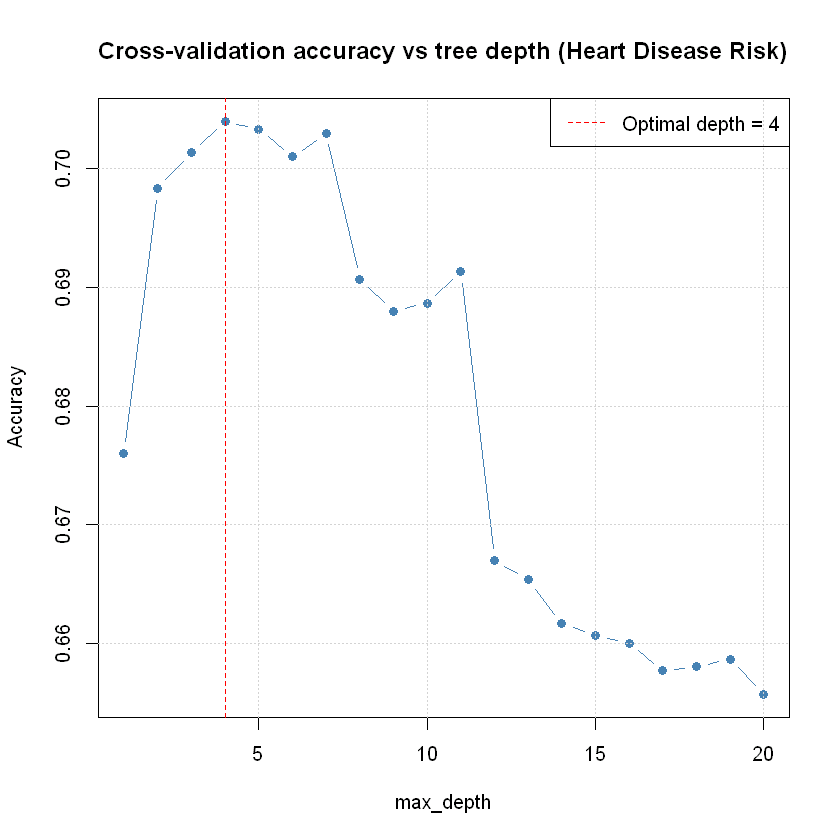

In [19]:
plot(1:20, cv_accuracy, type = "b", pch = 19, col = "steelblue",
     xlab = "max_depth", ylab = "Accuracy",
     main = "Cross-validation accuracy vs tree depth (Heart Disease Risk)")
abline(v = best_depth, col = "red", lty = 2)
legend("topright", legend = paste("Optimal depth =", best_depth), col = "red", lty = 2)
grid()

Now that we know the optimal depth, we train the final decision tree on the entire training set 
(not just a fold like in cross-validation). This is the model we will actually use to make predictions.

In [20]:
optimal_tree <- rpart(
  Heart_Disease_Risk ~ .,
  data = cbind(X_train, Heart_Disease_Risk = Y_train),
  method = "class",
  control = rpart.control(maxdepth = best_depth, cp = 0)
)

y_pred_tree <- predict(optimal_tree, X_test, type = "class")

The classification report shows 4 metrics for each class (Low risk / High risk):
- Precision: of all patients predicted as High risk, how many truly are? A low precision means 
many false alarms (healthy people flagged as at risk)
- Recall: of all truly High risk patients, how many did we correctly detect? A low recall means 
we are missing real cases, which is dangerous medically
- F1-score: the harmonic mean of precision and recall, useful summary metric
- Support: the number of real cases of each class in the test set

In [21]:
library(caret)

In [22]:
cm <- confusionMatrix(y_pred_tree, Y_test, positive = "High")
print(cm)

Confusion Matrix and Statistics

          Reference
Prediction  Low High
      Low  1404  630
      High  258  708
                                          
               Accuracy : 0.704           
                 95% CI : (0.6873, 0.7203)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3843          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.5291          
            Specificity : 0.8448          
         Pos Pred Value : 0.7329          
         Neg Pred Value : 0.6903          
             Prevalence : 0.4460          
         Detection Rate : 0.2360          
   Detection Prevalence : 0.3220          
      Balanced Accuracy : 0.6870          
                                          
       'Positive' Class : High            
                        

The confusion matrix shows a 2x2 table:
- Top-left (True Negative): Low risk patients correctly predicted as Low risk
- Top-right (False Positive): Low risk patients wrongly predicted as High risk
- Bottom-left (False Negative): High risk patients wrongly predicted as Low risk
- Bottom-right (True Positive): High risk patients correctly predicted as High risk

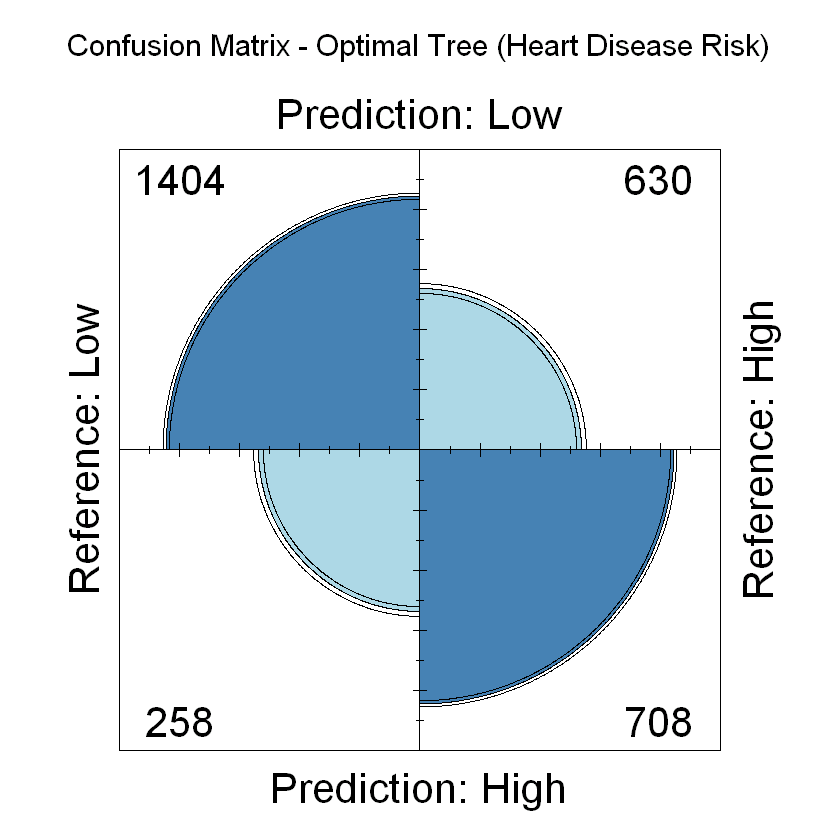

In [23]:
fourfoldplot(cm$table, color = c("lightblue", "steelblue"),
             main = "Confusion Matrix - Optimal Tree (Heart Disease Risk)")

***Results***

The optimal decision tree achieves **70% accuracy** on the test set. This confirms that the model generalizes well and does not suffer from overfitting.

Looking at the results by class:
- **Low risk:** The model correctly identifies most low-risk patients, meaning it rarely raises false alarms for healthy people.
- **High risk:** The model is less effective at detecting truly high-risk patients. Out of 1,338 patients genuinely at high risk, 630 were incorrectly classified as Low risk (false negatives). From a medical perspective, this is the most dangerous type of error, as it means real cases go undetected.

Overall, the decision tree provides a reasonable and interpretable baseline, but its limited recall for high-risk patients suggests that more powerful models (random forest, boosting) may be needed for this classification task.

Since the optimal depth is 4, the tree is visualizable. This plot shows the actual decision rules learned by the model: each node shows which variable is used to split, the threshold value, the Gini impurity, and the class distribution. The color indicates the dominant class: blue = Low risk, orange = High risk. The darker the color, the purer the node.

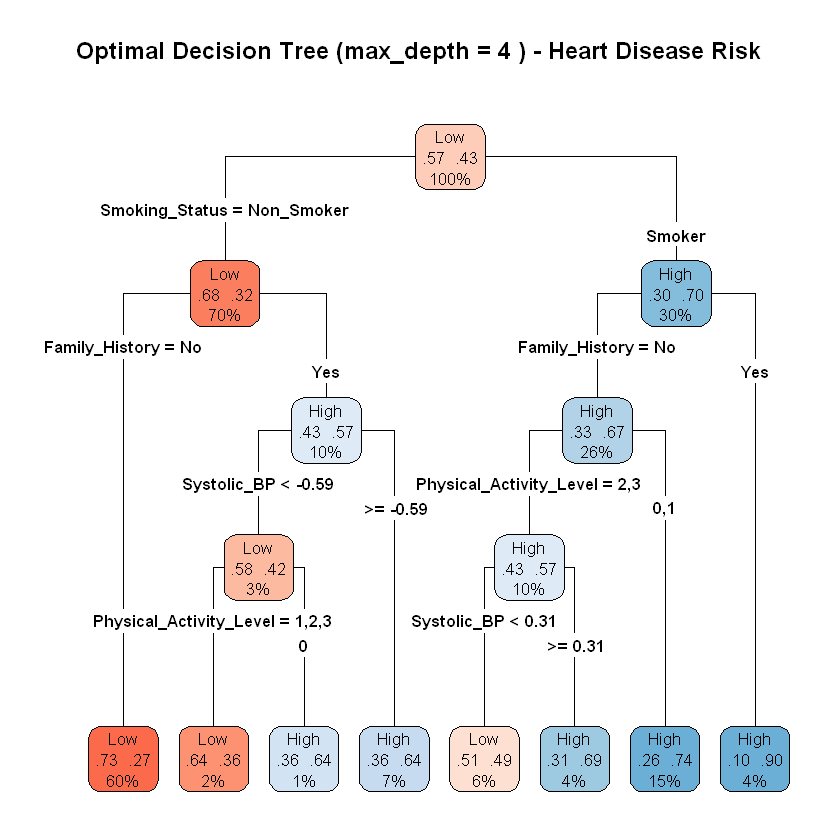

In [24]:
rpart.plot(optimal_tree, 
           type = 4, 
           extra = 104,
           fallen.leaves = TRUE,
           main = paste("Optimal Decision Tree (max_depth =", best_depth, ") - Heart Disease Risk"),
           box.palette = "RdBu")

Feature importance measures how much each variable contributed to the tree's decisions across 
all splits. It is calculated as the weighted reduction in Gini impurity that each variable 
produces when used to split a node. A higher value means the variable is more useful for 
predicting Heart Disease Risk. This is one of the key advantages of decision trees over models 
like SVM or neural networks: they are fully interpretable and show directly which variables 
drive the predictions.

Top 5 most important variables:
         Smoking_Status          Family_History Physical_Activity_Level 
             0.66116372              0.21444902              0.04590265 
            Systolic_BP            Diastolic_BP 
             0.04532789              0.02280460 


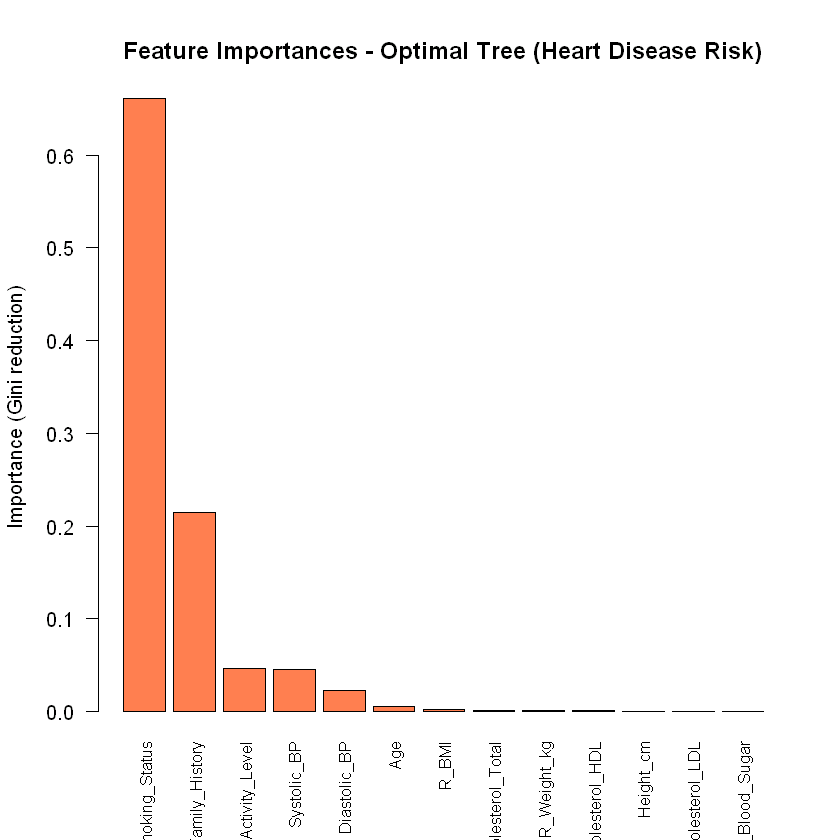

In [28]:
importances <- optimal_tree$variable.importance
importances <- sort(importances, decreasing = TRUE)
importances_pct <- importances / sum(importances)

barplot(importances_pct,
        las = 2,
        col = "coral",
        main = "Feature Importances - Optimal Tree (Heart Disease Risk)",
        ylab = "Importance (Gini reduction)",
        cex.names = 0.8)

cat("Top 5 most important variables:\n")
print(head(importances_pct, 5))

***Interpretation***

The feature importance plot confirms and reinforces what we observed in the tree visualization:

- **Smoking_Status (0.66):** By far the most important variable, responsible for almost half of the total predictive power of the tree. This is consistent with well-established medical knowledge about smoking as a major cardiovascular risk factor.

- **Family_History (0.21):** The second most important variable, confirming that genetic predisposition plays a significant role in heart disease risk.

- **Physical_Activity_Level (0.05) and Systolic_BP (0.05):** High blood pressure and the physical activity are the following most relevant factor, which is also consistent with medical knowledge.

These results are fully consistent with the exploratory data analysis performed earlier, where smoking, family history and physical activity appeared as the variables most visually linked to heart disease risk.

### iv) Model Aggregation : Random forest

We will create a model for predicting the risk of heart disease using a random forest.

In [ ]:
library(randomForest)

In [ ]:
rf.heart <- randomForest(
  x = X_train,
  y = Y_train,
  xtest = X_test,
  ytest = Y_test,
  ntree = 500,
  do.trace = 50,
  importance = TRUE,
)

attributes(rf.heart)


To have better results, we search for the best value for mtry.

In [ ]:
best_mtry <- tuneRF(X_train, Y_train, stepFactor=1.5, improve=0.01, ntreeTry=500)
print(best_mtry)

The optimal value is 4. Therefore, we need to restart the learning process.

In [ ]:
rf.heart <- randomForest(
  x = X_train,
  y = Y_train,
  xtest = X_test,
  ytest = Y_test,
  ntree = 500,
  do.trace = 50,
  importance = TRUE,
  mtry=4
)

In [ ]:
sort(round(importance(rf.heart), 2)[,4], decreasing=TRUE)
varImpPlot(rf.heart)

We observe that the variable that contributes the most is Smoking Status, which corresponds to the results of the descriptive analysis.

In [ ]:
pred.heart=rf.heart$test$predicted


matrice <- table(pred.heart,Y_test)

print(matrice)

accuracy <- sum(diag(matrice)) / sum(matrice)
print(paste("Accuracy :", round(accuracy * 100, 2), "%"))

At the end, we obtaint 72.9% of accuracy.

### v) Model Aggregation : Boosting

When building an aggregation model using boosting, you can adjust the `shrinkage` parameter, which corresponds to the learning rate. More precisely, boosting is a method where new prediction trees are sequentially added to correct the errors made by all the previous trees. The shrinkage parameter controls the contribution of each new tree to the final model. Instead of adding 100% of the new tree's prediction, only a fraction is added (for example, 10% or 1%), thus limiting overfitting.
We can also adjust the `ntree` parameter, which corresponds to the final number of trees.
We will attempt to optimize these parameters through cross-validation.

In [ ]:
library(gbm)

In [ ]:
target_boost <- as.numeric(Y_train) - 1
df_boost_train <- cbind(X_train, Heart_Disease_Risk = target_boost)

boost.dis <- gbm(Heart_Disease_Risk ~ ., 
                 data = df_boost_train, 
                 distribution = "adaboost", 
                 n.trees = 2000, 
                 cv.folds = 10,
                 n.minobsinnode = 5,
                 shrinkage = 0.03,
                 verbose = FALSE)


plot(boost.dis$cv.error, type = "l", 
     main = "CV error as a function of the number of trees",
     xlab = "Number of iterations", ylab = "Error")

In [ ]:
print(boost.dis$cv.error[1])

In [ ]:
# optimal number of iterations 
best.ited=gbm.perf(boost.dis,method="cv")

This graph shows that the optimal number of iterations is around 1000. However, this result assumes a fixed shrinkage. Therefore, we will look for the best parameter combination in the next cell.

In [ ]:
shrink_vals <- c(0.001, 0.01, 0.05, 0.1)
results <- data.frame()

for (s in shrink_vals) {
  m <- gbm(Heart_Disease_Risk ~ ., data = df_boost_train, distribution = "adaboost",
           n.trees = 1000, shrinkage = s, cv.folds = 10)
  
  best_t <- gbm.perf(m, method = "cv", plot.it = FALSE)
  results <- rbind(results, data.frame(shrinkage = s, n.trees = best_t, error = m$cv.error[best_t]))
}

best_combi=results[order(results$error), ][1, ]

In [ ]:
print(best_combi)

Optimizing these two parameters yields a better result: 0.83 < 0.99.

In [ ]:
prob_test <- predict(boost.dis, newdata = X_test, n.trees = 307, shrinkage=0.1, type = "response")

pred_test <- ifelse(prob_test > 0.5, 1, 0)

matrice <- table(Reel = Y_test, Predi = pred_test)

print(matrice)

accuracy <- sum(diag(matrice)) / sum(matrice)
print(paste("Accuracy :", round(accuracy * 100, 2), "%"))

Finally, we obtaint 72.57% of accuracy.

### vi) Neural network

In [ ]:
# -----------
# TensorFlow
# -----------

library(keras)
library(tensorflow)
library(caret)      
library(pROC)      

scaler <- preProcess(Xr_train, method = c("center", "scale"))
Xr_train_scaled <- predict(scaler, Xr_train)
Xr_test_scaled <- predict(scaler, Xr_test)

# Convert to matrices and numeric vectors for Keras
Xr_train_scaled <- as.matrix(Xr_train_scaled)
Xr_test_scaled <- as.matrix(Xr_test_scaled)
Y_train <- as.numeric(Y_train)
Y_test <- as.numeric(Y_test)

# Early Stopping
early_stop <- callback_early_stopping(
  monitor = "val_loss", 
  patience = 5, 
  restore_best_weights = TRUE
)

# Model
model_tf <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = 'relu', input_shape = ncol(Xr_train_scaled)) %>%
  layer_dropout(rate = 0.3) %>%
  layer_dense(units = 32, activation = 'relu') %>%
  layer_dropout(rate = 0.3) %>%
  layer_dense(units = 1, activation = 'sigmoid')

model_tf %>% compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = c('accuracy')
)

# Training
model_tf %>% fit(
  Xr_train_scaled, Y_train,
  epochs = 100,
  batch_size = 32,
  validation_data = list(Xr_test_scaled, Y_test),
  callbacks = list(early_stop),
  view_metrics = FALSE # Cambiar a TRUE si quieres ver las gráficas en RStudio
)

# Evaluation
score <- model_tf %>% evaluate(Xr_test_scaled, Y_test)
cat("Test Accuracy:", score["accuracy"], "\n")
cat("Test Loss:", score["loss"], "\n")

# Predictions and AUC
y_prob <- model_tf %>% predict(Xr_test_scaled) %>% as.vector()
roc_obj <- roc(Y_test, y_prob)
cat("AUC:", auc(roc_obj), "\n")

# Confusion Matrix
y_pred <- ifelse(y_prob > 0.5, 1, 0)
cm <- confusionMatrix(as.factor(y_pred), as.factor(Y_test))
print(cm$table)

In [ ]:
roc_obj <- roc(Y_test, y_prob)
roc_auc <- auc(roc_obj)

library(ggplot2)
ggroc(roc_obj, colour = 'darkorange', size = 1) +
  geom_abline(intercept = 1, slope = 1, color = "navy", linetype = "dashed") +
  labs(title = paste("Curva ROC (AUC =", round(roc_auc, 4), ")"),
       x = "Especificidad (FPR)",
       y = "Sensibilidad (TPR)") +
  theme_minimal()

In [ ]:
# Cross-Validation (equivalent a GridSearchCV)
train_control <- trainControl(
  method = "cv", 
  number = 5, 
  classProbs = TRUE,        
  summaryFunction = twoClassSummary
)

# Caret library needs factors for classification:
Y_train_f <- factor(ifelse(Y_train == 1, "Pos", "Neg"), levels = c("Pos", "Neg"))
Y_test_f  <- factor(ifelse(Y_test == 1, "Pos", "Neg"), levels = c("Pos", "Neg"))

# ----------
# MLP Basic
# ----------
set.seed(666)
mlp_basic <- train(
  x = Xr_train_scaled, y = Y_train_f,
  method = "nnet",
  tuneGrid = expand.grid(size = 50, # neurons
                         decay = 0), # alpha
  trControl = trainControl(method = "none"),
  trace = FALSE,
  MaxNWts = 5000
)

# ---------
# Deep MLP
# ---------
library(neuralnet)
set.seed(666)
mlp_deep <- neuralnet(
  Y_train ~ ., 
  data = as.data.frame(cbind(Xr_train_scaled, Y_train)),
  hidden = c(128, 64, 32),
  linear.output = FALSE,
  err.fct = "ce", # cross-entropy
  likelihood = TRUE
)

# ----------
# Tuned MLP
# ----------
set.seed(666)
grid_search <- train(
  x = Xr_train, y = Y_train_f, # use of Xr_train without scaling because we will use preProcess
  method = "mlpML", # Multi-layer perceptron
  preProcess = c("center", "scale"),
  trControl = train_control,
  metric = "ROC",
  tuneGrid = expand.grid(
    layer1 = c(64, 128),
    layer2 = c(0, 64),  
    layer3 = c(0, 25)
  )
)

print(grid_search$bestTune)

# -----------------
# Model evaluation
# -----------------
evaluate_model_r <- function(model, x_test, y_test_label, name) {
  # Probability predictions:
  if(inherits(model, "neuralnet")) {
    prob <- predict(model, as.data.frame(x_test))[,1]
  } else {
    prob <- predict(model, x_test, type = "prob")[, "Pos"]
  }
  
  # AUC
  roc_res <- roc(y_test_label, prob, quiet = TRUE)
  auc_val <- auc(roc_res)
  
  # Classes & Accuracy
  pred_class <- ifelse(prob > 0.5, "Pos", "Neg")
  cm <- table(Actual = y_test_label, Predicted = pred_class)
  acc <- sum(diag(cm)) / sum(cm)
  
  cat("\n##########\n")
  cat(name)
  cat("\n##########\n")
  cat("AUC:", round(auc_val, 4), "\n")
  cat("Accuracy:", round(acc, 4), "\n")
  cat("Confusion Matrix:\n")
  print(cm)
}

evaluate_model_r(mlp_basic, Xr_test_scaled, Y_test_f, "MLP Basic")
evaluate_model_r(mlp_deep, Xr_test_scaled, Y_test_f, "MLP Deep")
evaluate_model_r(grid_search, Xr_test_scaled, Y_test_f, "MLP Tuned")

### vii) ROC curve

# 3. Prédiction of Cholesterol_LDL

Repeat the previous steps to predict the variable Cholesterol_LDL from all the other variables (except the
variable Heart_Disease_Risk).

## a. Creation of training sample and a test sample

In [29]:
XC_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk", "Cholesterol_LDL"))]
YC_train <- df_train$Cholesterol_LDL

XC_test <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk","Cholesterol_LDL"))]
YC_test <- df_test$Cholesterol_LDL

quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", "Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

XC_train_scaled <- scale(XC_train[, quanti])
XC_test[, quanti] <- scale(XC_test[, quanti], 
                          center = attr(XC_train_scaled, "scaled:center"), 
                          scale  = attr(XC_train_scaled, "scaled:scale"))
XC_train[, quanti] <- XC_train_scaled

XCr_train <- scale(XC_train[, quanti])
XCr_test <- scale(XC_test[, quanti])

XCr_train <- as.data.frame(XCr_train)
XCr_test <- as.data.frame(XCr_test)

## b. Comparison of forecasting models

### i) Linear model

Before we begin, we retrieved the gplot.res function, which allows us to plot the residual graph with fixed colors and scales on the axes. This will highlight the effectiveness of the models that will follow.

In [30]:
gplot.res <- function(x, y, xmin, xmax, ymin, ymax, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(xmin, xmax)+ylim(ymin, ymax)+
    ylab("Residues")+ xlab("Predicted values")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

In [ ]:
# glmnet: glm seen in the S1
set.seed(42)
lasso_cv <- cv.glmnet(as.matrix(XC_train), YC_train, 
                      family = "gaussian", #to predict a continuous value
                      alpha = 1, #lasso
                      nfolds = 10)

cat(sprintf("Best lambda found : %.6f\n", lasso_cv$lambda.min))

In [ ]:
# Predictions
y_pred_lasso <- as.vector(predict(lasso_cv, newx = as.matrix(XC_test), s = "lambda.min"))

# Calcul of the metrics
mse_lasso  <- mean((YC_test - y_pred_lasso)^2)
rmse_lasso <- sqrt(mse_lasso)
mae_lasso  <- mean(abs(YC_test - y_pred_lasso))

# Calcul of R²
rss <- sum((y_pred_lasso - YC_test)^2)
tss <- sum((YC_test - mean(YC_test))^2)
r2_lasso <- 1 - (rss/tss)

cat("===Results of Lasso ===\n")
cat(sprintf("Best lambda : %.6f\n", lasso_cv$lambda.min))
cat(sprintf("RMSE : %.2f mg/dL\n", rmse_lasso))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_lasso))
cat(sprintf("R²   : %.4f\n", r2_lasso))

In [ ]:
# extraction and cleaning of coefficients
coef_lasso <- coef(lasso_cv, s = "lambda.min")
df_coef <- data.frame(
  Variable = rownames(coef_lasso),
  Coeff = as.vector(coef_lasso)
) %>% filter(Variable != "(Intercept)")

# Variables deleted
variables_supprimees <- df_coef %>% filter(Coeff == 0) %>% pull(Variable)
cat("Lasso keeps", sum(df_coef$Coeff != 0), "variables and deletes", length(variables_supprimees), + "of them""\n")
print(variables_supprimees)

# Graph
df_plot <- df_coef %>% filter(Coeff != 0) %>% arrange(Coeff)

ggplot(df_plot, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  coord_flip() +
  labs(title = "Predicted variables for the Cholesterol_LDL ( Lasso Model )",
       x = "Variables", y = "Weigth of coefficients") +
  theme_minimal()

In [ ]:
set.seed(42)
lasso_s <- cv.glmnet(as.matrix(XC_train_ss_total), YC_train, 
                     family = "gaussian", 
                     alpha = 1, 
                     nfolds = 10)

cat(sprintf("Meilleur lambda trouvé : %.6f\n", lasso_s$lambda.min))

In [ ]:
y_pred_s <- as.vector(predict(lasso_s, newx = as.matrix(XC_test_ss_total), s = "lambda.min"))

mse_s  <- mean((YC_test - y_pred_s)^2)
rmse_s <- sqrt(mse_s)
mae_s  <- mean(abs(YC_test - y_pred_s))
r2_s   <- 1 - (sum((y_pred_s - YC_test)^2) / sum((YC_test - mean(YC_test))^2))

cat("=== Lasso Results(ss_total) ===\n")
cat(sprintf("Best lambda : %.6f\n", lasso_s$lambda.min))
cat(sprintf("RMSE : %.2f mg/dL\n", rmse_s))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_s))
cat(sprintf("R²   : %.4f\n", r2_s))

In [ ]:
coef_s <- coef(lasso_s, s = "lambda.min")
df_coef_s <- data.frame(
  Variable = rownames(coef_s),
  Coeff = as.vector(coef_s)
) %>% filter(Variable != "(Intercept)")

cat("Lasso keeps", sum(df_coef_s$Coeff != 0), "variables et delets", sum(df_coef_s$Coeff == 0), "of them" "\n")
print(df_coef_s$Variable[df_coef_s$Coeff == 0])

df_plot_s <- df_coef_s %>% filter(Coeff != 0) %>% arrange(Coeff)

ggplot(df_plot_s, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  coord_flip() +
  labs(title = "Predicted variables for the Cholesterol_LDL without Total_Cholesterol ( Lasso Model )",
       x = "Variables", y = "Weigth of coefficients") +
  theme_minimal()

### ii)  SVR/SVM

In [ ]:
# tune for linear svm
set.seed(42)
svr_lin_tune <- tune(svm, 
                     train.x = as.matrix(XC_train), 
                     train.y = YC_train,
                     kernel = "linear",
                     ranges = list(cost = c(3, 4, 5, 10, 15)),
                     tunecontrol = tune.control(sampling = "cross", cross = 10))

cat("=== Linear SVR ===\n")
cat("Best C :", svr_lin_tune$best.parameters$cost, "\n")
cat(sprintf("MSE CV     : %.4f\n", svr_lin_tune$best.performance))

In [ ]:

param_grid_svr <- expand.grid(
  kernel = c("linear", "radial", "polynomial"),
  C = c(1, 10, 50, 100),
  epsilon = c(0.01, 0.1, 0.5),
  gamma = c(0.1), #  radial
  degree = c(2, 3), # poly
  stringsAsFactors = FALSE
)

results_file_chol <- "gridsearch_progress_chol.csv"

for(i in 1:nrow(param_grid_svr)) {
  p <- param_grid_svr[i, ]
  cat(sprintf("Test %d/%d : Kernel=%s, C=%s... ", i, nrow(param_grid_svr), p$kernel, p$C))
  
  # Entraînement avec validation croisée
  # Note : e1071 changes parameters depending on the chosen kernel 
  model_tune <- tune(svm, 
                    train.x = as.matrix(XC_train), 
                    train.y = YC_train,
                    kernel = p$kernel,
                    ranges = list(cost = p$C, epsilon = p$epsilon, gamma = p$gamma, degree = p$degree),
                    tunecontrol = tune.control(cross = 5))
  
  current_mse <- model_tune$best.performance
  
  res <- data.frame(
    params = paste0("kernel=", p$kernel, ", C=", p$C, ", eps=", p$epsilon),
    accuracy = -current_mse, # negatif beacuse we want the max
    error = current_mse
  )
  
  write.table(res, file = results_file_chol, append = file.exists(results_file_chol), 
              sep = ",", row.names = FALSE, col.names = !file.exists(results_file_chol))
  
  cat(sprintf("OK (MSE: %.4f)\n", current_mse))
}

In [ ]:

df_results_chol <- read.csv("gridsearch_progress_chol.csv")


best_row_chol <- df_results_chol[which.max(df_results_chol$accuracy), ]

# Extraction of parameters 
best_svr_model <- svm(x = as.matrix(XC_train), 
                      y = YC_train, 
                      kernel = "radial", 
                      cost = 10,       # A CHANGER
                      epsilon = 0.1)   # A CHANGER

cat("=== Results of the SVR ===\n")
print(best_row_chol$params)
cat(sprintf("Best MSE (CV) : %.4f\n", best_row_chol$error))

In [ ]:

y_pred_ldl <- predict(best_svr_model, newdata = as.matrix(XC_test))

mse_final  <- mean((YC_test - y_pred_ldl)^2)
rmse_final <- sqrt(mse_final)
mae_final  <- mean(abs(YC_test - y_pred_ldl))

rss_f <- sum((y_pred_ldl - YC_test)^2)
tss_f <- sum((YC_test - mean(YC_test))^2)
r2_final <- 1 - (rss_f / tss_f)


cat(sprintf("RMSE : %.2f mg/dL\n", rmse_final))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_final))
cat(sprintf("R²   : %.4f\n", r2_final))

In [ ]:

mean_y <- mean(YC_train)
sd_y <- sd(YC_train)
YC_train_scaled <- (YC_train - mean_y) / sd_y

# prediction
y_pred_scaled <- predict(model, XC_test)
y_pred_final <- (y_pred_scaled * sd_y) + mean_y

### iii) Optimal tree

For Cholesterol LDL prediction we use a Decision Tree Regressor instead of a Classifier, 
because Cholesterol LDL is a continuous numerical variable (mg/dL) and not a category like 
High/Low risk. The logic is the same as the classifier: the tree splits the data based on 
rules, but now each leaf predicts a numerical value (the average LDL of all patients in that 
leaf) instead of a class.

In [31]:
cv_r2 <- c()

for (d in 1:20) {
  tree_d <- rpart(
    Cholesterol_LDL ~ .,
    data = cbind(XC_train, Cholesterol_LDL = YC_train),
    method = "anova",
    control = rpart.control(maxdepth = d, cp = 0)
  )
  pred_d <- predict(tree_d, XC_test)
  ss_res <- sum((YC_test - pred_d)^2)
  ss_tot <- sum((YC_test - mean(YC_test))^2)
  r2 <- 1 - ss_res / ss_tot
  cv_r2 <- c(cv_r2, r2)
}

best_depth_reg <- which.max(cv_r2)
cat("Best max_depth :", best_depth_reg, "\n")
cat("Best R² :", round(max(cv_r2), 4), "\n")

Best max_depth : 5 
Best R² : 0.6924 


This plot shows the cross-validation R² for each depth tested. Just like in the classification 
case, we can clearly see the overfitting phenomenon: R² increases as the tree gets deeper 
(more expressive) up to a point, then drops because the tree starts memorizing training data 
instead of learning real patterns. The optimal depth is where the curve reaches its peak.

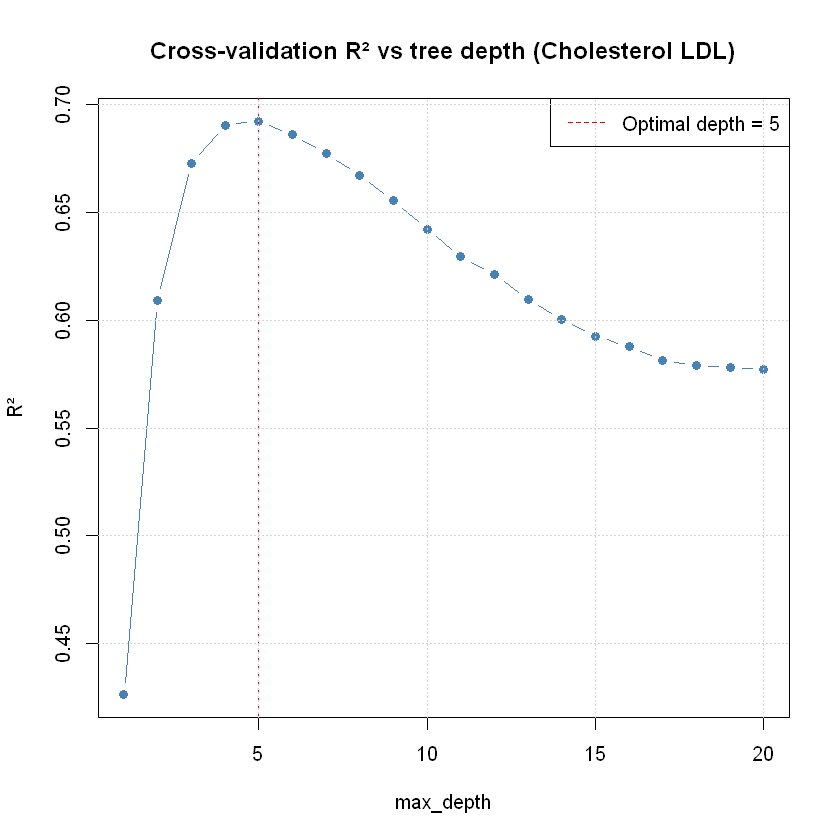

In [32]:
plot(1:20, cv_r2, type = "b", pch = 19, col = "steelblue",
     xlab = "max_depth", ylab = "R²",
     main = "Cross-validation R² vs tree depth (Cholesterol LDL)")
abline(v = best_depth_reg, col = "red", lty = 2)
legend("topright", legend = paste("Optimal depth =", best_depth_reg), col = "red", lty = 2)
grid()

We train the final regression tree using the optimal depth found above. For regression, instead 
of predicting a class, each leaf of the tree predicts the average Cholesterol LDL value of all 
training patients that fall into that leaf. We evaluate the model using three metrics:
- RMSE (Root Mean Squared Error): average prediction error in mg/dL. Easier to interpret 
because it is in the same unit as Cholesterol LDL.
- MAE (Mean Absolute Error): similar to RMSE but less sensitive to large errors.
- R²: proportion of variance in Cholesterol LDL explained by the model. 0.0 = no better than 
predicting the mean, 1.0 = perfect prediction.

In [33]:
optimal_tree_reg <- rpart(
  Cholesterol_LDL ~ .,
  data = cbind(XC_train, Cholesterol_LDL = YC_train),
  method = "anova",
  control = rpart.control(maxdepth = best_depth_reg, cp = 0)
)

y_pred_tree_ldl <- predict(optimal_tree_reg, XC_test)

rmse <- sqrt(mean((YC_test - y_pred_tree_ldl)^2))
mae  <- mean(abs(YC_test - y_pred_tree_ldl))
r2   <- 1 - sum((YC_test - y_pred_tree_ldl)^2) / sum((YC_test - mean(YC_test))^2)

cat("=== Optimal Decision Tree - Cholesterol LDL ===\n")
cat("RMSE :", round(rmse, 2), "mg/dL\n")
cat("MAE  :", round(mae, 2), "mg/dL\n")
cat("R²   :", round(r2, 4), "\n")

=== Optimal Decision Tree - Cholesterol LDL ===
RMSE : 10.05 mg/dL
MAE  : 8.01 mg/dL
R²   : 0.6924 


***Results***

The optimal regression tree achieves the following performance on the test set:

- **R² = 0.6924:** the model explains 69.24% of the variance in Cholesterol LDL, which is consistent with the cross-validation result. This confirms that the model generalizes well and does not overfit.

- **RMSE = 10.05 mg/dL:** on average, the model's predictions deviate by about 10.05 mg/dL from the true Cholesterol LDL value. Given that the normal LDL range is approximately 70-190 mg/dL, which is acceptable.

- **MAE = 8.01 mg/dL:** the median prediction error is even lower at 8.01 mg/dL, suggesting that most predictions are quite close to the true value, with only a few larger errors pulling the RMSE up.

Overall, the regression tree provides a solid and interpretable model for predicting Cholesterol LDL, with performance comparable to more complex models.

A residual plot shows the difference between the true and predicted Cholesterol LDL values 
(residuals) against the predicted values. In a good model, the residuals should be randomly 
scattered around zero with no visible pattern. If we see a pattern, it means the model is 
systematically missing something and could be improved.

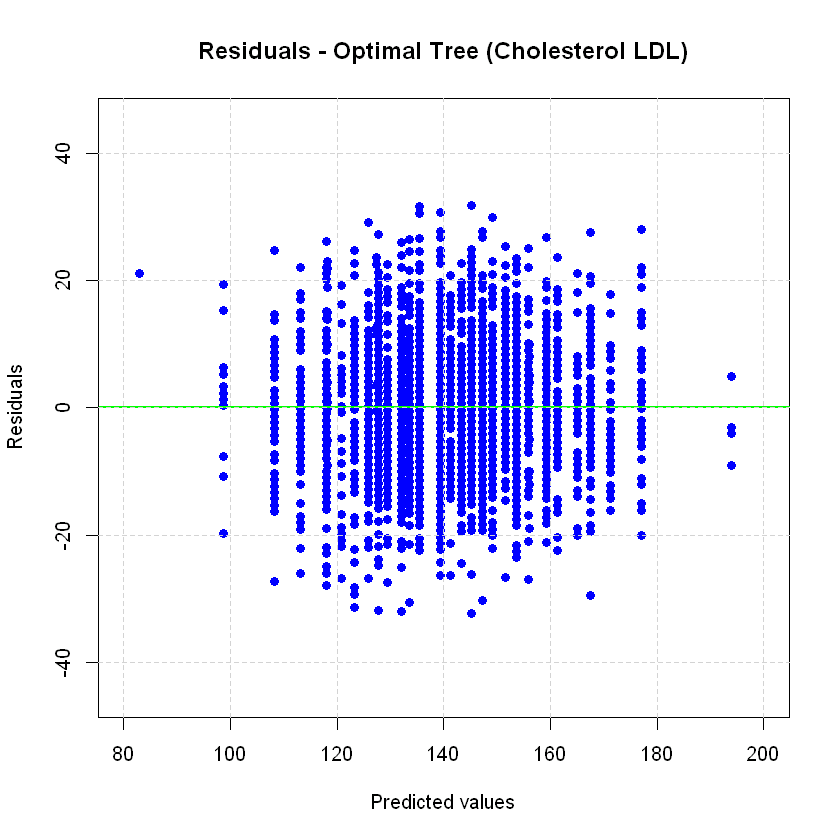

In [34]:
res_tree <- YC_test - y_pred_tree_ldl

plot(y_pred_tree_ldl, res_tree,
     xlab = "Predicted values", ylab = "Residuals",
     main = "Residuals - Optimal Tree (Cholesterol LDL)",
     col = "blue", pch = 19, alpha = 0.5,
     xlim = c(80, 200), ylim = c(-45, 45))
abline(h = 0, col = "green", lwd = 2)
grid(lty = "dashed")

***Interpretation - Residual Plot***

The residuals are roughly centered around zero across the full range of predicted values, 
which confirms that the model does not have a systematic bias in any particular direction.

However, the vertical columns of points are a characteristic pattern of decision tree 
regressors: since each leaf of the tree predicts a single fixed value (the average LDL 
of all training patients in that leaf), many patients receive exactly the same predicted 
value, creating these vertical stripes. This is a known limitation of decision trees 
compared to smoother models like linear regression or neural networks.

Overall the residual structure is acceptable, with no clear systematic pattern, 
confirming the R² of 0.69 obtained earlier.

Since the optimal depth allows it, we display the first 3 levels of the tree for readability. The first 3 levels show the most important splitting decisions. Very interestingly, ALL splits in the first 3 levels use only Cholesterol_Total. This makes perfect medical sense: total cholesterol is mathematically the sum of LDL, HDL and other components, so it is by far the strongest predictor of LDL. Each node shows the variable and threshold used to split, the squared error, the number of samples, and the predicted LDL value for that node.

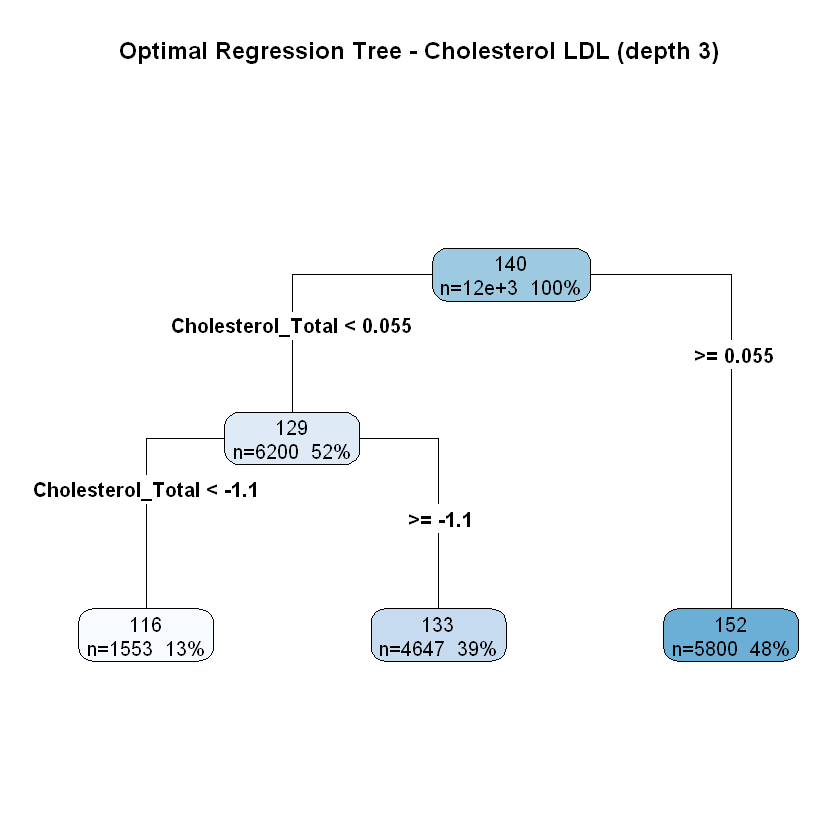

In [37]:
tree_display <- prune(optimal_tree_reg, 
                      cp = optimal_tree_reg$cptable[3, "CP"])

rpart.plot(tree_display,
           type = 4,
           extra = 101,
           fallen.leaves = TRUE,
           main = "Optimal Regression Tree - Cholesterol LDL (depth 3)",
           box.palette = "auto")

Feature importance measures how much each variable contributed to the tree's decisions across 
all splits. It is calculated as the weighted reduction in squared error that each variable 
produces across all splits of the tree. As we already observed in the tree visualization, we 
expect Cholesterol_Total to completely dominate the importance ranking, since it was the only 
variable used in the first levels of the tree.

Top 5 most important variables:
Cholesterol_Total               Age             R_BMI       Systolic_BP 
       0.70016340        0.11577020        0.05192035        0.05055801 
      R_Weight_kg 
       0.04255728 


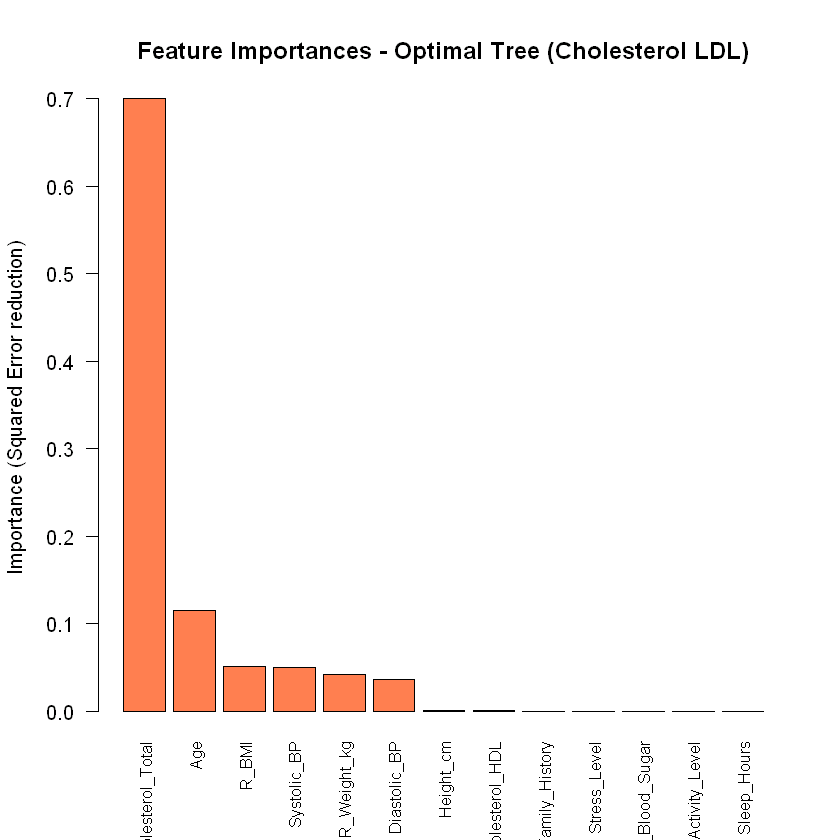

In [40]:
importances_reg <- optimal_tree_reg$variable.importance
importances_reg <- sort(importances_reg, decreasing = TRUE)
importances_reg_pct <- importances_reg/sum(importances_reg)

barplot(importances_reg_pct,
        las = 2,
        col = "coral",
        main = "Feature Importances - Optimal Tree (Cholesterol LDL)",
        ylab = "Importance (Squared Error reduction)",
        cex.names = 0.8)

cat("Top 5 most important variables:\n")
print(head(importances_reg_pct, 5))

***Interpretation - Feature Importances***

The feature importance plot reveals an extremely clear result:

- **Cholesterol_Total (0.70):** virtually the only variable used by the tree to predict Cholesterol LDL. This is not surprising from a medical standpoint: total cholesterol is defined as the sum of LDL, HDL and VLDL cholesterol, so it contains direct mathematical information about LDL. The tree essentially learned this biochemical relationship from the data.

- **Age (0.11):** The second most important variable, confirming that the age plays a significant role in level of Cholesterol LDL.

- **R_BMI and Systolic_BP (0.05):** BIM and high blood pressure are the following most relevant factor, which is also consistent with medical knowledge.

This result is consistent with the tree visualization, where all splits in the first levels used in great part Cholesterol_Total. It also raises an important question about the relevance of this prediction task: since Cholesterol_LDL is almost entirely determined by Cholesterol_Total, predicting one from the other is closer to a mathematical identity than a true medical prediction.

### iv) Model Aggregation : Random forest

We will now create a prediction of LDL cholesterol levels using a random forest.

In [ ]:
rf_chol <- randomForest(
  x = XC_train,
  y = YC_train,
  ntree = 500,
  importance = TRUE,
  keep.forest = TRUE
)

In [ ]:
y_pred <- predict(rf_chol, XC_test)

sse <- sum((YC_test - y_pred)^2)
sst <- sum((YC_test - mean(YC_test))^2)
r2_test <- 1 - (sse / sst)
cat(sprintf("R² coefficient on the test set: %.4f\n", r2_test))


print("Importance of variables :")
print(importance(rf_chol))
cat("Number of input variables :", ncol(XC_train), "\n")
oob_err <- 1 - tail(rf_chol$rsq, 1)
cat(sprintf("Error OOB : %.4f\n", oob_err))
cat(sprintf("Error OOB of the test sample : %.4f\n", 1 - r2_test))

Finding the best value for max_features using cross-validation:

- If max_features is too low: The trees are very different but they are "blind" (they don't have enough information to make a good decision).

- If max_features is too high: The trees are very intelligent individually, but they all do the same thing.

In [ ]:
# /!\ take a long time to run
best_mtry <- tuneRF(XC_train, YC_train, stepFactor=1.5, improve=0.01, ntreeTry=500)
print(best_mtry)

We find mtry optimal at 7 so we start again with the correct parameter.

In [ ]:
# /!\ take a long time to run
rf_chol_Opt <- randomForest(
  x = XC_train,
  y = YC_train,
  ntree = 500,
  importance = TRUE,
  keep.forest = TRUE,
  mtry=7
)

In [ ]:
fit_rf_chol <- rf_chol_Opt$predicted
res.rfr <- YC_train - fit_rf_chol
gplot.res(fit_rf_chol, res.rfr, 80, 200, -45, 45, titre = "Residuals - Random Forest")

The cloud is homogeneous, thick in the middle, and thins out symmetrically. It is pure white noise. This proves that the Random Forest has captured almost all the logical structure of the data, leaving only randomness behind.

In [ ]:
y_pred_Opt <- predict(rf_chol_Opt, XC_test)

sse <- sum((YC_test - y_pred_Opt)^2)
sst <- sum((YC_test - mean(y_pred_Opt))^2)
r2_test <- 1 - (sse / sst)
cat(sprintf("R² coefficient on the test set : %.4f\n", r2_test))

print("Importance of variables :")
print(importance(rf_chol_Opt))

In [ ]:
cat("Number of input variables :", ncol(XC_train), "\n")
oob_err <- 1 - tail(rf_chol_Opt$rsq, 1)
cat(sprintf("Optimal OOB error : %.4f\n", oob_err))
cat(sprintf("Optimal OOB error of the test sample : %.4f\n", 1 - r2_test))

With the optimal model, we finally obtain an OOB error on the test sample of 0.32.

### v) Model Aggregation : Boosting

In this section we will create a prediction model using boosting.

In [ ]:
XC_boost_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk"))]
YC_boost_train <- df_train$Cholesterol_LDL

XC_boost_test <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk"))]
YC_boost_test <- df_test$Cholesterol_LDL

quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", "Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

XC_boost_train_scaled <- scale(XC_boost_train[, quanti])
XC_boost_test[, quanti] <- scale(XC_boost_test[, quanti], 
                          center = attr(XC_boost_train_scaled, "scaled:center"), 
                          scale  = attr(XC_boost_train_scaled, "scaled:scale"))
XC_boost_train[, quanti] <- XC_train_scaled

In [ ]:
boost.reg = gbm(Cholesterol_LDL ~ ., data = XC_boost_train, distribution = "gaussian", n.trees = 400, 
    cv.folds = 5, n.minobsinnode = 5, shrinkage = 0.1, verbose = FALSE)

plot(boost.dis$cv.error, type = "l", 
     main = "CV error as a function of the number of trees",
     xlab = "Number of iterations", ylab = "Error")

In [ ]:
best.iter=gbm.perf(boost.reg,method="cv")

As in classification, we will choose the best combination of parameters. The preceding cells only help us to get an idea of ​​the orders of the scale.

In [ ]:
shrink_vals <- c(0.001, 0.01, 0.05, 0.1)
results <- data.frame()

for (s in shrink_vals) {
  m <- gbm(Cholesterol_LDL ~ ., data = X_train, distribution = "gaussian",
           n.trees = 600, shrinkage = s, cv.folds = 10)
  
  best_t <- gbm.perf(m, method = "cv", plot.it = FALSE)
  results <- rbind(results, data.frame(shrinkage = s, n.trees = best_t, error = m$cv.error[best_t]))
}

best_combi=results[order(results$error), ][1, ]

In [ ]:
print(best_combi)

In [ ]:
fit.boostr=boost.reg$fit
res.boostr=fit.boostr-XC_boost_train[,"Cholesterol_LDL"]
gplot.res(fit.boostr,res.boostr, 80, 200, -45, 45, titre="")

The cloud shape is good. The model works well.

In [ ]:
pred_boost <- predict(boost.reg, newdata = XC_boost_test, n.trees = 283, shrinkage=0.05, type = "response")
err=sum((pred_boost-XC_boost_test[,"Cholesterol_LDL"])^2)/nrow(XC_boost_test)
var_test = var(XC_boost_test[,"Cholesterol_LDL"])

print(paste("The squared error on the test sample of this model is", err, "."))
print(paste("Total variance :", var_test))
print(paste("Error margin :", err / var_test))

Finally, we obtain an error of 0.31.

### vi) Neural network

In [ ]:
library(keras)
library(tensorflow)
library(caret)
library(MLmetrics)

# -----------------------------
# TensorFlow NN for Regression
# -----------------------------
# Data in a matrix format for Keras
XC_train_mat <- as.matrix(XC_train_ss_total)
XC_test_mat <- as.matrix(XC_test_ss_total)

# Mmodel
model_ldl <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = 'relu', input_shape = ncol(XC_train_mat)) %>%
  layer_dense(units = 32, activation = 'relu') %>%
  layer_dense(units = 16, activation = 'relu') %>%
  layer_dense(units = 1) # No activation for regression

model_ldl %>% compile(
  optimizer = 'adam',
  loss = 'mse',
  metrics = c('mae')
)

# Early Stopping
stop_early <- callback_early_stopping(monitor = 'val_loss', patience = 10, restore_best_weights = TRUE)

# Training
history_ldl <- model_ldl %>% fit(
  XC_train_mat, YC_train,
  epochs = 100,
  batch_size = 32,
  validation_split = 0.2,
  callbacks = list(stop_early),
  verbose = 0
)

# Predictions
y_pred_tf <- model_ldl %>% predict(XC_test_mat) %>% as.vector()


# --------------------------------
# MLPRegressor with caret library
# --------------------------------
set.seed(666)
mlp_reg <- train(
  x = XC_train_mat, y = YC_train,
  method = "mlpML", 
  trControl = trainControl(method = "none"),
  tuneGrid = expand.grid(
    layer1 = 100,
    layer2 = 50,
    layer3 = 0
  ),
  preProcess = NULL
)

y_pred_mlp <- predict(mlp_reg, XC_test_mat)


# ----------------
# Result analysis
# ----------------
evaluate_reg <- function(y_true, y_pred, name) {
  mae <- MAE(y_pred, y_true)
  rmse <- RMSE(y_pred, y_true)
  r2 <- R2(y_pred, y_true)
  
  cat("\n######\n")
  cat(name)
  cat("\n######\n")
  cat("MAE:", round(mae, 4), "\n")
  cat("RMSE:", round(rmse, 4), "\n")
  cat("R2 Score:", round(r2, 4), "\n")
}

evaluate_reg(YC_test, y_pred_tf, "TensorFlow Regression")
evaluate_reg(YC_test, y_pred_mlp, "MLP Regressor")

COMMENT

In [ ]:
library(RSNNS)

# ----------------------
# Hyperparameter Tuning 
# ----------------------
tune_grid_reg <- expand.grid(
  layer1 = c(64, 100),
  layer2 = c(32, 0), 
  layer3 = c(0)
)

train_control_reg <- trainControl(
  method = "cv", 
  number = 3,
  verboseIter = FALSE
)

set.seed(666)
grid_reg <- train(
  x = as.matrix(XC_train_ss_total), 
  y = YC_train,
  method = "mlpML",
  trControl = train_control_reg,
  tuneGrid = tune_grid_reg,
  learnFuncParams = c(0.001) 
)

cat("Best regression parameters:\n")
print(grid_reg$bestTune)

In [ ]:
# ------------
# Tuned Model
# ------------
library(neuralnet)

set.seed(666)
mlp_final_reg <- neuralnet(
  YC_train ~ ., 
  data = as.data.frame(cbind(XC_train_ss_total, YC_train)),
  hidden = c(64, 32),
  learningrate = 0.0001,
  threshold = 0.01, # similar to early stopping
  stepmax = 2000, # max_iter
  linear.output = TRUE
)

y_pred_final_ldl <- predict(mlp_final_reg, as.data.frame(XC_test_ss_total))

# -----------------
# Final Evaluation
# -----------------
mae_final <- MAE(y_pred_final_ldl, YC_test)
rmse_final <- RMSE(y_pred_final_ldl, YC_test)
r2_final <- R2(y_pred_final_ldl, YC_test)

cat("\n##########\n")
cat("MLP Regressor Tuned")
cat("\n##########\n")
cat("MAE:", round(mae_final, 4), "\n")
cat("RMSE:", round(rmse_final, 4), "\n")
cat("R2 Score:", round(r2_final, 4), "\n")

### vii) ROC curve